# Build a Customer Support Bot

Customer support bots can free up teams' time by handling routine issues, but it can be hard to build a bot that reliably handles diverse tasks in a way that doesn't leave the user pulling their hair out.

You have to build a customer support bot for an airline to help users research, make travel arrangements and manage a user's flight bookings, hotel reservations, car rentals, and excursions.




Let's start!

## Prerequisites

First, set up your environment. Download the test DB, and define the tools we will reuse in each section.

While most of our tools will connect to a local sqlite database (and require no additional dependencies), we will also provide a general web search to the agent using Tavily.

In [1]:
!pip install -U langgraph langchain-community langchain-anthropic tavily-python pandas openai langchain_huggingface langchain_chroma langchain_openai langchain_groq

In [2]:
import getpass
import os

def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"Please provide your {var}")

_set_if_undefined("OPENAI_API_KEY") # USE YOUR CHOICE OF MODEL.
_set_if_undefined("TAVILY_API_KEY")
_set_if_undefined("GROQ_API_KEY")


Please provide your OPENAI_API_KEY··········
Please provide your TAVILY_API_KEY··········
Please provide your GROQ_API_KEY··········


#### Populate the database

Run the next script to fetch a `sqlite` DB and update it to look like it's current.

In [3]:
!pip install pandas --quiet
import os
import shutil
import sqlite3

import pandas as pd
import requests

db_url = "https://storage.googleapis.com/benchmarks-artifacts/travel-db/travel2.sqlite"
local_file = "travel2.sqlite"

backup_file = "travel2.backup.sqlite"
overwrite = False
if overwrite or not os.path.exists(local_file):
    response = requests.get(db_url)
    response.raise_for_status()  # Ensure the request was successful
    with open(local_file, "wb") as f:
        f.write(response.content)
    # Backup - we will use this to "reset" our DB in each section
    shutil.copy(local_file, backup_file)

# Convert the flights to present time
def update_dates(file):
    shutil.copy(backup_file, file)
    conn = sqlite3.connect(file)
    cursor = conn.cursor()

    tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table';", conn
    ).name.tolist()
    tdf = {}
    for t in tables:
        tdf[t] = pd.read_sql(f"SELECT * from {t}", conn)

    example_time = pd.to_datetime(
        tdf["flights"]["actual_departure"].replace("\\N", pd.NaT)
    ).max()
    current_time = pd.to_datetime("now").tz_localize(example_time.tz)
    time_diff = current_time - example_time

    tdf["bookings"]["book_date"] = (
        pd.to_datetime(tdf["bookings"]["book_date"].replace("\\N", pd.NaT), utc=True)
        + time_diff
    )

    datetime_columns = [
        "scheduled_departure",
        "scheduled_arrival",
        "actual_departure",
        "actual_arrival",
    ]
    for column in datetime_columns:
        tdf["flights"][column] = (
            pd.to_datetime(tdf["flights"][column].replace("\\N", pd.NaT)) + time_diff
        )

    for table_name, df in tdf.items():
        df.to_sql(table_name, conn, if_exists="replace", index=False)
    del df
    del tdf
    conn.commit()
    conn.close()

    return file

db = update_dates(local_file)

## Tools

Next, define our assistant's tools to search the airline's policy manual and search and manage reservations for flights, hotels, car rentals, and excursions.





#### Lookup Company Policies

The assistant retrieve policy information to answer user questions. Note that _enforcement_ of these policies still must be done within the tools/APIs themselves, since the LLM can always ignore this.

In [4]:
!pip install sentence-transformers
import re
from langchain_huggingface import HuggingFaceEmbeddings
import numpy as np
from langchain_core.tools import tool
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.document_loaders import TextLoader
from langchain_chroma import Chroma
from langchain_core.documents import Document


response = requests.get(
    "https://storage.googleapis.com/benchmarks-artifacts/travel-db/swiss_faq.md"
)
response.raise_for_status()
faq_text = response.text

docs = [{"page_content": txt} for txt in re.split(r"(?=\n##)", faq_text)]

class VectorStoreRetriever:
    def __init__(self, docs: list[dict], embedding_model: str = "sentence-transformers/all-MiniLM-L6-v2"):
        self.embedding = HuggingFaceEmbeddings(model_name=embedding_model)
        documents = [Document(page_content=doc["page_content"], metadata={k: v for k, v in doc.items() if k != "page_content"}) for doc in docs]
        self.vectorstore = Chroma.from_documents(documents, self.embedding)

    @classmethod
    def from_docs(cls, docs: list[dict], embedding_model: str = "sentence-transformers/all-MiniLM-L6-v2"):
        return cls(docs, embedding_model)

    def query(self, query: str, k: int = 5) -> list[dict]:
        results = self.vectorstore.similarity_search_with_relevance_scores(query, k=k)
        return [
            {
                **doc.metadata,
                "page_content": doc.page_content,
                "similarity": score
            }
            for doc, score in results
        ]
retriever = VectorStoreRetriever.from_docs(docs)


@tool
def lookup_policy(query: str) -> str:
    """Consult the company policies to check whether certain options are permitted.
    Use this before making any flight changes performing other 'write' events."""

    results = retriever.query(query, k=2)

    return "\n\n".join([doc["page_content"] for doc in results])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


#### Flights

Define the (`fetch_user_flight_information`) tool to let the agent see the current user's flight information.  Then define tools to search for flights and manage the passenger's bookings stored in the SQL database.

We the can [access the RunnableConfig](https://python.langchain.com/docs/how_to/tool_configure/#inferring-by-parameter-type) for a given run to check the `passenger_id` of the user accessing this application. The LLM never has to provide these explicitly, they are provided for a given invocation of the graph so that each user cannot access other passengers' booking information.




In [5]:
import sqlite3
from datetime import date, datetime
from typing import Optional

import pytz
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool # Import the tool decorator

@tool # Add the tool decorator
def fetch_user_flight_information(config: RunnableConfig) -> list[dict]:
    """Fetch all tickets for the user along with corresponding flight information and seat assignments.

    Returns:
        A list of dictionaries where each dictionary contains the ticket details,
        associated flight details, and the seat assignments for each ticket belonging to the user.
    """
    configuration = config.get("configurable", {})
    passenger_id = configuration.get("passenger_id", None)
    if not passenger_id:
        raise ValueError("No passenger ID configured.")

    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    query = """
    SELECT
        t.ticket_no, t.book_ref,
        f.flight_id, f.flight_no, f.departure_airport, f.arrival_airport, f.scheduled_departure, f.scheduled_arrival,
        bp.seat_no, tf.fare_conditions
    FROM
        tickets t
        JOIN ticket_flights tf ON t.ticket_no = tf.ticket_no
        JOIN flights f ON tf.flight_id = f.flight_id
        JOIN boarding_passes bp ON bp.ticket_no = t.ticket_no AND bp.flight_id = f.flight_id
    WHERE
        t.passenger_id = ?
    """
    cursor.execute(query, (passenger_id,))
    rows = cursor.fetchall()
    column_names = [column[0] for column in cursor.description]
    results = [dict(zip(column_names, row)) for row in rows]

    cursor.close()
    conn.close()

    return results

@tool # Add the tool decorator
def search_flights(
    departure_airport: Optional[str] = None,
    arrival_airport: Optional[str] = None,
    start_time: Optional[date | datetime] = None,
    end_time: Optional[date | datetime] = None,
    limit: int = 20,
) -> list[dict]:
    """Search for flights based on departure airport, arrival airport, and departure time range."""
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    query = "SELECT * FROM flights WHERE 1 = 1"
    params = []

    if departure_airport:
        query += " AND departure_airport = ?"
        params.append(departure_airport)

    if arrival_airport:
        query += " AND arrival_airport = ?"
        params.append(arrival_airport)

    if start_time:
        query += " AND scheduled_departure >= ?"
        params.append(start_time)

    if end_time:
        query += " AND scheduled_departure <= ?"
        params.append(end_time)
    query += " LIMIT ?"
    params.append(limit)
    cursor.execute(query, params)
    rows = cursor.fetchall()
    column_names = [column[0] for column in cursor.description]
    results = [dict(zip(column_names, row)) for row in rows]

    cursor.close()
    conn.close()

    return results

@tool # Add the tool decorator
def update_ticket_to_new_flight(
    ticket_no: str, new_flight_id: int, *, config: RunnableConfig
) -> str:
    """Update the user's ticket to a new valid flight."""
    configuration = config.get("configurable", {})
    passenger_id = configuration.get("passenger_id", None)
    if not passenger_id:
        raise ValueError("No passenger ID configured.")

    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute(
        "SELECT departure_airport, arrival_airport, scheduled_departure FROM flights WHERE flight_id = ?",
        (new_flight_id,),
    )
    new_flight = cursor.fetchone()
    if not new_flight:
        cursor.close()
        conn.close()
        return "Invalid new flight ID provided."
    column_names = [column[0] for column in cursor.description]
    new_flight_dict = dict(zip(column_names, new_flight))
    timezone = pytz.timezone("Etc/GMT-3")
    current_time = datetime.now(tz=timezone)
    departure_time = datetime.strptime(
        new_flight_dict["scheduled_departure"], "%Y-%m-%d %H:%M:%S.%f%z"
    )
    time_until = (departure_time - current_time).total_seconds()
    if time_until < (3 * 3600):
        return f"Not permitted to reschedule to a flight that is less than 3 hours from the current time. Selected flight is at {departure_time}."

    cursor.execute(
        "SELECT flight_id FROM ticket_flights WHERE ticket_no = ?", (ticket_no,)
    )
    current_flight = cursor.fetchone()
    if not current_flight:
        cursor.close()
        conn.close()
        return "No existing ticket found for the given ticket number."

    # Check the signed-in user actually has this ticket
    cursor.execute(
        "SELECT * FROM tickets WHERE ticket_no = ? AND passenger_id = ?",
        (ticket_no, passenger_id),
    )
    current_ticket = cursor.fetchone()
    if not current_ticket:
        cursor.close()
        conn.close()
        return f"Current signed-in passenger with ID {passenger_id} not the owner of ticket {ticket_no}"

    # In a real application, you'd likely add additional checks here to enforce business logic,
    # like "does the new departure airport match the current ticket", etc.
    # While it's best to try to be *proactive* in 'type-hinting' policies to the LLM
    # it's inevitably going to get things wrong, so you **also** need to ensure your
    # API enforces valid behavior
    cursor.execute(
        "UPDATE ticket_flights SET flight_id = ? WHERE ticket_no = ?",
        (new_flight_id, ticket_no),
    )
    conn.commit()

    cursor.close()
    conn.close()
    return "Ticket successfully updated to new flight."

@tool # Add the tool decorator
def cancel_ticket(ticket_no: str, *, config: RunnableConfig) -> str:
    """Cancel the user's ticket and remove it from the database."""
    configuration = config.get("configurable", {})
    passenger_id = configuration.get("passenger_id", None)
    if not passenger_id:
        raise ValueError("No passenger ID configured.")
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute(
        "SELECT flight_id FROM ticket_flights WHERE ticket_no = ?", (ticket_no,)
    )
    existing_ticket = cursor.fetchone()
    if not existing_ticket:
        cursor.close()
        conn.close()
        return "No existing ticket found for the given ticket number."

    # Check the signed-in user actually has this ticket
    cursor.execute(
        "SELECT flight_id FROM tickets WHERE ticket_no = ? AND passenger_id = ?",
        (ticket_no, passenger_id),
    )
    current_ticket = cursor.fetchone()
    if not current_ticket:
        cursor.close()
        conn.close()
        return f"Current signed-in passenger with ID {passenger_id} not the owner of ticket {ticket_no}"

    cursor.execute("DELETE FROM ticket_flights WHERE ticket_no = ?", (ticket_no,))
    conn.commit()

    cursor.close()
    conn.close()
    return "Ticket successfully cancelled."

#### Car Rental Tools

Once a user books a flight, they likely will want to organize transportation. Define some "car rental" tools to let the user search for and reserve a car at their destination.

In [6]:
from datetime import date, datetime
from typing import Optional, Union
from langchain_core.tools import tool

@tool
def search_car_rentals(
    location: Optional[str] = None,
    name: Optional[str] = None,
    price_tier: Optional[str] = None,
    start_date: Optional[Union[datetime, date]] = None,
    end_date: Optional[Union[datetime, date]] = None,
) -> list[dict]:
    """
    Search for car rentals based on location, name, price tier, start date, and end date.

    Args:
        location (Optional[str]): The location of the car rental. Defaults to None.
        name (Optional[str]): The name of the car rental company. Defaults to None.
        price_tier (Optional[str]): The price tier of the car rental. Defaults to None.
        start_date (Optional[Union[datetime, date]]): The start date of the car rental. Defaults to None.
        end_date (Optional[Union[datetime, date]]): The end date of the car rental. Defaults to None.

    Returns:
        list[dict]: A list of car rental dictionaries matching the search criteria.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    query = "SELECT * FROM car_rentals WHERE 1=1"
    params = []

    if location:
        query += " AND location LIKE ?"
        params.append(f"%{location}%")
    if name:
        query += " AND name LIKE ?"
        params.append(f"%{name}%")
    # For our tutorial, we will let you match on any dates and price tier.
    # (since our toy dataset doesn't have much data)
    cursor.execute(query, params)
    results = cursor.fetchall()

    conn.close()

    return [
        dict(zip([column[0] for column in cursor.description], row)) for row in results
    ]

@tool
def book_car_rental(rental_id: int) -> str:
    """
    Book a car rental by its ID.

    Args:
        rental_id (int): The ID of the car rental to book.

    Returns:
        str: A message indicating whether the car rental was successfully booked or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute("UPDATE car_rentals SET booked = 1 WHERE id = ?", (rental_id,))
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Car rental {rental_id} successfully booked."
    else:
        conn.close()
        return f"No car rental found with ID {rental_id}."

@tool
def update_car_rental(
    rental_id: int,
    start_date: Optional[Union[datetime, date]] = None,
    end_date: Optional[Union[datetime, date]] = None,
) -> str:
    """
    Update a car rental's start and end dates by its ID.

    Args:
        rental_id (int): The ID of the car rental to update.
        start_date (Optional[Union[datetime, date]]): The new start date of the car rental. Defaults to None.
        end_date (Optional[Union[datetime, date]]): The new end date of the car rental. Defaults to None.

    Returns:
        str: A message indicating whether the car rental was successfully updated or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    if start_date:
        cursor.execute(
            "UPDATE car_rentals SET start_date = ? WHERE id = ?",
            (start_date, rental_id),
        )
    if end_date:
        cursor.execute(
            "UPDATE car_rentals SET end_date = ? WHERE id = ?", (end_date, rental_id)
        )

    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Car rental {rental_id} successfully updated."
    else:
        conn.close()
        return f"No car rental found with ID {rental_id}."

@tool
def cancel_car_rental(rental_id: int) -> str:
    """
    Cancel a car rental by its ID.

    Args:
        rental_id (int): The ID of the car rental to cancel.

    Returns:
        str: A message indicating whether the car rental was successfully cancelled or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute("UPDATE car_rentals SET booked = 0 WHERE id = ?", (rental_id,))
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Car rental {rental_id} successfully cancelled."
    else:
        conn.close()
        return f"No car rental found with ID {rental_id}."

#### Hotels

The user has to sleep! Define some tools to search for and manage hotel reservations.

In [7]:
from langchain_core.tools import tool # Import the tool decorator

@tool
def search_hotels(
    location: Optional[str] = None,
    name: Optional[str] = None,
    price_tier: Optional[str] = None,
    checkin_date: Optional[Union[datetime, date]] = None,
    checkout_date: Optional[Union[datetime, date]] = None,
) -> list[dict]:
    """
    Search for hotels based on location, name, price tier, check-in date, and check-out date.

    Args:
        location (Optional[str]): The location of the hotel. Defaults to None.
        name (Optional[str]): The name of the hotel. Defaults to None.
        price_tier (Optional[str]): The price tier of the hotel. Defaults to None. Examples: Midscale, Upper Midscale, Upscale, Luxury
        checkin_date (Optional[Union[datetime, date]]): The check-in date of the hotel. Defaults to None.
        checkout_date (Optional[Union[datetime, date]]): The check-out date of the hotel. Defaults to None.

    Returns:
        list[dict]: A list of hotel dictionaries matching the search criteria.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    query = "SELECT * FROM hotels WHERE 1=1"
    params = []

    if location:
        query += " AND location LIKE ?"
        params.append(f"%{location}%")
    if name:
        query += " AND name LIKE ?"
        params.append(f"%{name}%")
    # For the sake of this tutorial, we will let you match on any dates and price tier.
    cursor.execute(query, params)
    results = cursor.fetchall()

    conn.close()

    return [
        dict(zip([column[0] for column in cursor.description], row)) for row in results
    ]

@tool
def book_hotel(hotel_id: int) -> str:
    """
    Book a hotel by its ID.

    Args:
        hotel_id (int): The ID of the hotel to book.

    Returns:
        str: A message indicating whether the hotel was successfully booked or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute("UPDATE hotels SET booked = 1 WHERE id = ?", (hotel_id,))
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Hotel {hotel_id} successfully booked."
    else:
        conn.close()
        return f"No hotel found with ID {hotel_id}."

@tool
def update_hotel(
    hotel_id: int,
    checkin_date: Optional[Union[datetime, date]] = None,
    checkout_date: Optional[Union[datetime, date]] = None,
) -> str:
    """
    Update a hotel's check-in and check-out dates by its ID.

    Args:
        hotel_id (int): The ID of the hotel to update.
        checkin_date (Optional[Union[datetime, date]]): The new check-in date of the hotel. Defaults to None.
        checkout_date (Optional[Union[datetime, date]]): The new check-out date of the hotel. Defaults to None.

    Returns:
        str: A message indicating whether the hotel was successfully updated or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    if checkin_date:
        cursor.execute(
            "UPDATE hotels SET checkin_date = ? WHERE id = ?", (checkin_date, hotel_id)
        )
    if checkout_date:
        cursor.execute(
            "UPDATE hotels SET checkout_date = ? WHERE id = ?",
            (checkout_date, hotel_id),
        )

    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Hotel {hotel_id} successfully updated."
    else:
        conn.close()
        return f"No hotel found with ID {hotel_id}."

@tool
def cancel_hotel(hotel_id: int) -> str:
    """
    Cancel a hotel by its ID.

    Args:
        hotel_id (int): The ID of the hotel to cancel.

    Returns:
        str: A message indicating whether the hotel was successfully cancelled or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute("UPDATE hotels SET booked = 0 WHERE id = ?", (hotel_id,))
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Hotel {hotel_id} successfully cancelled."
    else:
        conn.close()
        return f"No hotel found with ID {hotel_id}."

#### Excursions

Finally, define some tools to let the user search for things to do (and make reservations) once they arrive.

In [8]:
@tool
def search_trip_recommendations(
    location: Optional[str] = None,
    name: Optional[str] = None,
    keywords: Optional[str] = None,
) -> list[dict]:
    """
    Search for trip recommendations based on location, name, and keywords.

    Args:
        location (Optional[str]): The location of the trip recommendation. Defaults to None.
        name (Optional[str]): The name of the trip recommendation. Defaults to None.
        keywords (Optional[str]): The keywords associated with the trip recommendation. Defaults to None.

    Returns:
        list[dict]: A list of trip recommendation dictionaries matching the search criteria.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    query = "SELECT * FROM trip_recommendations WHERE 1=1"
    params = []

    if location:
        query += " AND location LIKE ?"
        params.append(f"%{location}%")
    if name:
        query += " AND name LIKE ?"
        params.append(f"%{name}%")
    if keywords:
        keyword_list = keywords.split(",")
        keyword_conditions = " OR ".join(["keywords LIKE ?" for _ in keyword_list])
        query += f" AND ({keyword_conditions})"
        params.extend([f"%{keyword.strip()}%" for keyword in keyword_list])

    cursor.execute(query, params)
    results = cursor.fetchall()

    conn.close()

    return [
        dict(zip([column[0] for column in cursor.description], row)) for row in results
    ]

@tool
def book_excursion(recommendation_id: int) -> str:
    """
    Book a excursion by its recommendation ID.

    Args:
        recommendation_id (int): The ID of the trip recommendation to book.

    Returns:
        str: A message indicating whether the trip recommendation was successfully booked or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute(
        "UPDATE trip_recommendations SET booked = 1 WHERE id = ?", (recommendation_id,)
    )
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Trip recommendation {recommendation_id} successfully booked."
    else:
        conn.close()
        return f"No trip recommendation found with ID {recommendation_id}."

@tool
def update_excursion(recommendation_id: int, details: str) -> str:
    """
    Update a trip recommendation's details by its ID.

    Args:
        recommendation_id (int): The ID of the trip recommendation to update.
        details (str): The new details of the trip recommendation.

    Returns:
        str: A message indicating whether the trip recommendation was successfully updated or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute(
        "UPDATE trip_recommendations SET details = ? WHERE id = ?",
        (details, recommendation_id),
    )
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Trip recommendation {recommendation_id} successfully updated."
    else:
        conn.close()
        return f"No trip recommendation found with ID {recommendation_id}."

@tool
def cancel_excursion(recommendation_id: int) -> str:
    """
    Cancel a trip recommendation by its ID.

    Args:
        recommendation_id (int): The ID of the trip recommendation to cancel.

    Returns:
        str: A message indicating whether the trip recommendation was successfully cancelled or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute(
        "UPDATE trip_recommendations SET booked = 0 WHERE id = ?", (recommendation_id,)
    )
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Trip recommendation {recommendation_id} successfully cancelled."
    else:
        conn.close()
        return f"No trip recommendation found with ID {recommendation_id}."

#### Utilities

Define helper functions to pretty print the messages in the graph while we debug it and to give our tool node error handling (by adding the error to the chat history).

In [9]:
from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableLambda

from langgraph.prebuilt import ToolNode

def handle_tool_error(state) -> dict:
    error = state.get("error")
    tool_calls = state["messages"][-1].tool_calls
    return {
        "messages": [
            ToolMessage(
                content=f"Error: {repr(error)}\n please fix your mistakes.",
                tool_call_id=tc["id"],
            )
            for tc in tool_calls
        ]
    }

def create_tool_node_with_fallback(tools: list) -> dict:
    return ToolNode(tools).with_fallbacks(
        [RunnableLambda(handle_tool_error)], exception_key="error"
    )

def _print_event(event: dict, _printed: set, max_length=1500):
    current_state = event.get("dialog_state")
    if current_state:
        print("Currently in: ", current_state[-1])
    message = event.get("messages")
    if message:
        if isinstance(message, list):
            message = message[-1]
        if message.id not in _printed:
            msg_repr = message.pretty_repr(html=True)
            if len(msg_repr) > max_length:
                msg_repr = msg_repr[:max_length] + " ... (truncated)"
            print(msg_repr)
            _printed.add(message.id)

## Building Agent

When building, it's best to start with the simplest working implementation. All else equal, prefer simple, scalable solutions to complicated ones. In this case, the single-graph approach has limitations. The bot may take undesired actions without user confirmation, struggle with complex queries, and lack focus in its responses. We'll address these issues later.

In this section, we will define a simple Zero-shot agent as the assistant, give the agent **all** of our tools, and prompt it to use them judiciously to assist the user.




Start by defining the state.

#### State

Define our `StateGraph`'s state as a typed dictionary containing an append-only list of messages. These messages form the chat history, which is all the state our simple assistant needs.

In [10]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import AnyMessage, add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

#### Agent

Next, define the assistant function. This function takes the graph state, formats it into a prompt, and then calls an LLM for it to predict the best response.

In [11]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import Runnable, RunnableConfig
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic # Import ChatAnthropic
# from langchain_groq import ChatGroq # Import ChatGroq

class Assistant:
    def __init__(self, runnable: Runnable):
        self.runnable = runnable

    def __call__(self, state: State, config: RunnableConfig):
      while True:
          configuration = config.get("configurable", {})
          passenger_id = configuration.get("passenger_id", None)
          state = {**state, "user_info": passenger_id}
          result = self.runnable.invoke(state)
          # If the LLM happens to return an empty response, we will re-prompt it
          # for an actual response.
          if not result.tool_calls and (
              not result.content
              or isinstance(result.content, list)
              and not result.content[0].get("text")
          ):
              messages = state["messages"] + [("user", "Respond with a real output.")]
              state = {**state, "messages": messages}
          else:
              break
      return {"messages": result}

llm = ChatOpenAI(model="gpt-4o") # Comment out or remove this line
#llm = ChatAnthropic(model="claude-3-5-sonnet-20240620") # Use ChatAnthropic with your desired model
#llm = ChatGroq(model="llama-3.1-8b-instant") # Use ChatGroq with your desired model

primary_assistant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful customer support assistant for a flight booking company. "
            "Use the provided tools to answer questions and manage flights, "
            "hotels, car rentals, and excursions for the user. "
            "Be polite and professional.", # TODO: << WRITE A GOOD SYSTEM PROMPT>>,
        ),
        ("placeholder", "{messages}"),
    ]
).partial(time=datetime.now)

part_1_tools = [
    TavilySearchResults(max_results=3), # Use the new class name
    lookup_policy,
    fetch_user_flight_information,
    search_flights,
    update_ticket_to_new_flight,
    cancel_ticket]
part_1_assistant_runnable = primary_assistant_prompt | llm.bind_tools(part_1_tools)

/tmp/ipython-input-4290619870.py:49: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  TavilySearchResults(max_results=3), # Use the new class name


#### Define Graph

Now, create the graph. The graph is the final assistant for this section.

In [12]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import tools_condition

builder = StateGraph(State)

# Define nodes: these do the work
assistant = Assistant(part_1_assistant_runnable)
builder.add_node("assistant", assistant)
builder.add_node("tools", create_tool_node_with_fallback(part_1_tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_edge("tools", "assistant")
builder.add_conditional_edges(
    "assistant",  # From the assistant
    tools_condition,  # Draw edges based on the messages' content
    # If the messages contain a tool_call, route to the tools node
    {"tools": "tools", END: END},
)

# The checkpointer lets the graph persist its state
# this is a complete memory for the entire graph.
checkpointer = MemorySaver()

part_1_graph = builder.compile(checkpointer=checkpointer)

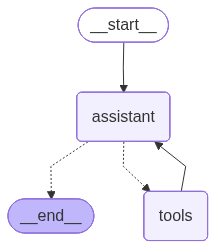

In [13]:
from IPython.display import Image, display

try:
    display(Image(part_1_graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

#### Example Conversation

Now it's time to try out our mighty chatbot! Let's run it over the following list of dialog turns. If it hits a "RecursionLimit", that means the agent wasn't able to get an answer in the allocated number of steps. That's OK!

In [14]:
import shutil
import uuid

# Let's create an example conversation a user might have with the assistant
questions = [
    "Hi there, what time is my flight?",
    "Am i allowed to update my flight to something sooner? I want to leave later today.",
    "Update my flight to sometime next week then",
    "The next available option is great",
    "what about lodging and transportation?",
    "Yeah i think i'd like an affordable hotel for my week-long stay (7 days). And I'll want to rent a car.",
    "OK could you place a reservation for your recommended hotel? It sounds nice.",
    "yes go ahead and book anything that's moderate expense and has availability.",
    "Now for a car, what are my options?",
    "Awesome let's just get the cheapest option. Go ahead and book for 7 days",
    "Cool so now what recommendations do you have on excursions?",
    "Are they available while I'm there?",
    "interesting - i like the museums, what options are there? ",
    "OK great pick one and book it for my second day there.",
]

# Update with the backup file so we can restart from the original place in each section
db = update_dates(db)
thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        # The passenger_id is used in our flight tools to
        # fetch the user's flight information
        "passenger_id": "3442 587242",
        # Checkpoints are accessed by thread_id
        "thread_id": thread_id,
    }
}


_printed = set()
for question in questions:
    events = part_1_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

Hi there, what time is my flight?
================================== Ai Message ==================================
Tool Calls:
  fetch_user_flight_information (call_59AzQiwFnwzenuF4Onws6EL2)
 Call ID: call_59AzQiwFnwzenuF4Onws6EL2
  Args:
================================= Tool Message =================================
Name: fetch_user_flight_information

[{"ticket_no": "7240005432906569", "book_ref": "C46E9F", "flight_id": 19250, "flight_no": "LX0112", "departure_airport": "CDG", "arrival_airport": "BSL", "scheduled_departure": "2025-10-22 07:38:59.127649-04:00", "scheduled_arrival": "2025-10-22 09:08:59.127649-04:00", "seat_no": "18E", "fare_conditions": "Economy"}]
================================== Ai Message ==================================

Your flight LX0112 is scheduled to depart from Charles de Gaulle Airport (CDG) at 07:38 AM on October 22, 2025, and arrive at EuroAirport Basel Mulhouse Freibur

#### Agent: Review

What are your observations?

## Conditional Interrupt

We'll refine our interrupt strategy by categorizing tools as safe (read-only) or sensitive (data-modifying). We'll apply interrupts to the sensitive tools only, allowing the bot to handle simple queries autonomously.

This balances user control and conversational flow, but as we add more tools, our single graph may grow too complex for this "flat" structure. We'll address that in the next section.



In [15]:
from typing import Annotated
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import Runnable, RunnableConfig
from typing_extensions import TypedDict

from langgraph.graph.message import AnyMessage, add_messages


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    user_info: str

class Assistant:
    def __init__(self, runnable: Runnable):
        self.runnable = runnable

    def __call__(self, state: State, config: RunnableConfig):
        while True:
            result = self.runnable.invoke(state)
            # If the LLM happens to return an empty response, we will re-prompt it
            # for an actual response.
            if not result.tool_calls and (
                not result.content
                or isinstance(result.content, list)
                and not result.content[0].get("text")
            ):
                messages = state["messages"] + [("user", "Respond with a real output.")]
                state = {**state, "messages": messages}
            else:
                break
        return {"messages": result}

llm = ChatOpenAI(model="gpt-4-turbo-preview")

assistant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful customer support assistant for an airline. "
            "Your goal is to assist users with their travel arrangements, "
            "including flight bookings, hotel reservations, car rentals, and excursions. "
            "Be polite, professional, and use the provided tools to fulfill user requests. "
            "Always confirm with the user before making any modifications to their bookings.",
        ),
        ("placeholder", "{messages}"),
    ]
).partial(time=datetime.now)


# "Read"-only tools (such as retrievers) don't need a user confirmation to use
part_3_safe_tools = [
    TavilySearchResults(max_results=3),
    lookup_policy,
    fetch_user_flight_information,
    search_flights,
    search_car_rentals,
    search_hotels,
    search_trip_recommendations,
]

# These tools all change the user's reservations.
# The user has the right to control what decisions are made
part_3_sensitive_tools = [
    update_ticket_to_new_flight,
    cancel_ticket,
    book_car_rental,
    update_car_rental,
    cancel_car_rental,
    book_hotel,
    update_hotel,
    cancel_hotel,
    book_excursion,
    update_excursion,
    cancel_excursion,
]
sensitive_tool_names = {t.name for t in part_3_sensitive_tools}
# Our LLM doesn't have to know which nodes it has to route to. In its 'mind', it's just invoking functions.
part_3_assistant_runnable = assistant_prompt | llm.bind_tools(
    part_3_safe_tools + part_3_sensitive_tools
)

#### Define Graph

Now, create the graph. Our graph is almost identical to part 2 **except** we split out the tools into 2 separate nodes. We only interrupt before the tools that are actually making changes to the user's bookings.

In [18]:
from typing import Literal

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition

builder = StateGraph(State)


def user_info(state: State):
    return {"user_info": fetch_user_flight_information.invoke({})}


# NEW: The fetch_user_info node runs first, meaning our assistant can see the user's flight information without
# having to take an action
builder.add_node("fetch_user_info", user_info)
builder.add_edge(START, "fetch_user_info")

assistant = Assistant(part_3_assistant_runnable)
builder.add_node("assistant", assistant)
builder.add_node("safe_tools", create_tool_node_with_fallback(part_3_safe_tools))
builder.add_node("sensitive_tools", create_tool_node_with_fallback(part_3_sensitive_tools))


# Define logic
builder.add_edge("fetch_user_info", "assistant")


def route_tools(state: State):
    next_node = tools_condition(state)
    # If no tools are invoked, return to the user
    if next_node == END:
        return END
    ai_message = state["messages"][-1]
    # This assumes single tool calls. To handle parallel tool calling, you'd want to
    # use an ANY condition
    first_tool_call = ai_message.tool_calls[0]
    if first_tool_call["name"] in sensitive_tool_names:
        return "sensitive_tools"
    return "safe_tools"



builder.add_conditional_edges(
    "assistant",  # From the assistant
    route_tools,  # Draw edges based on the messages' content
    # If the messages contain a tool_call, route to the tools node
    {"safe_tools": "safe_tools", "sensitive_tools": "sensitive_tools", END: END},
)


builder.add_edge("safe_tools", "assistant")
builder.add_edge("sensitive_tools", "assistant")



checkpointer = MemorySaver()
part_3_graph = builder.compile(


    checkpointer=checkpointer,
    # NEW: The graph will always halt before executing the "tools" node.
    # The user can approve or reject (or even alter the request) before
    # the assistant continues

    interrupt_before=["sensitive_tools"]
)

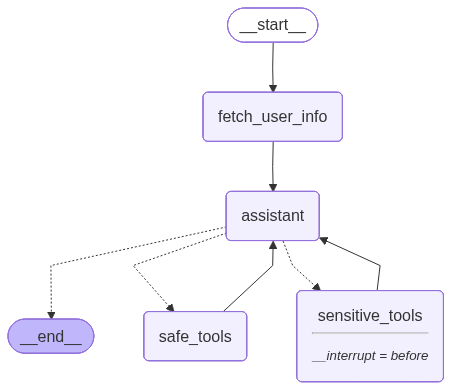

In [19]:
from IPython.display import Image, display

try:
    display(Image(part_3_graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

#### Example Conversation

Now it's time to try out our newly revised chatbot! Let's run it over the following list of dialog turns. This time, we'll have many fewer confirmations.

In [20]:
import shutil
import uuid

# Update with the backup file so we can restart from the original place in each section
db = update_dates(db)
thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        # The passenger_id is used in our flight tools to
        # fetch the user's flight information
        "passenger_id": "3442 587242",
        # Checkpoints are accessed by thread_id
        "thread_id": thread_id,
    }
}

questions = [
    "Hi there, what time is my flight?",
    "Am i allowed to update my flight to something sooner? I want to leave later today.",
    "Update my flight to sometime next week then",
    "The next available option is great",
    "what about lodging and transportation?",
    "Yeah i think i'd like an affordable hotel for my week-long stay (7 days). And I'll want to rent a car.",
    "OK could you place a reservation for your recommended hotel? It sounds nice.",
    "yes go ahead and book anything that's moderate expense and has availability.",
    "Now for a car, what are my options?",
    "Awesome let's just get the cheapest option. Go ahead and book for 7 days",
    "Cool so now what recommendations do you have on excursions?",
    "Are they available while I'm there?",
    "interesting - i like the museums, what options are there? ",
    "OK great pick one and book it for my second day there.",
]


_printed = set()
# We can reuse the tutorial questions from part 1 to see how it does.
for question in questions:
    events = part_3_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)
    snapshot = part_3_graph.get_state(config)
    while snapshot.next:
        # We have an interrupt! The agent is trying to use a tool, and the user can approve or deny it
        # Note: This code is all outside of your graph. Typically, you would stream the output to a UI.
        # Then, you would have the frontend trigger a new run via an API call when the user has provided input.
        try:
            user_input = input(
                "Do you approve of the above actions? Type 'y' to continue;"
                " otherwise, explain your requested changed.\n\n"
            )
        except:
            user_input = "y"
        if user_input.strip() == "y":
            # Just continue
            result = part_3_graph.invoke(
                None,
                config,
            )
        else:
            # Satisfy the tool invocation by
            # providing instructions on the requested changes / change of mind
            result = part_3_graph.invoke(
                {
                    "messages": [
                        ToolMessage(
                            tool_call_id=event["messages"][-1].tool_calls[0]["id"],
                            content=f"API call denied by user. Reasoning: '{user_input}'. Continue assisting, accounting for the user's input.",
                        )
                    ]
                },
                config,
            )
        snapshot = part_3_graph.get_state(config)

================================ Human Message =================================

Hi there, what time is my flight?
================================== Ai Message ==================================
Tool Calls:
  fetch_user_flight_information (call_BwbA5HrI8oEhIUbjkIRvVor9)
 Call ID: call_BwbA5HrI8oEhIUbjkIRvVor9
  Args:
================================= Tool Message =================================
Name: fetch_user_flight_information

[{"ticket_no": "7240005432906569", "book_ref": "C46E9F", "flight_id": 19250, "flight_no": "LX0112", "departure_airport": "CDG", "arrival_airport": "BSL", "scheduled_departure": "2025-10-22 07:44:15.483156-04:00", "scheduled_arrival": "2025-10-22 09:14:15.483156-04:00", "seat_no": "18E", "fare_conditions": "Economy"}]
================================== Ai Message ==================================

Your flight LX0112 is scheduled to depart from CDG (Charles de Gaulle Airport) to BSL (EuroAirport Basel Mulhouse Freiburg) on October 22, 2025, at 07:44 AM loc

/tmp/ipython-input-1670871133.py:32: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='024bb8a5-ee0c-4737-9ea8-5040d2e2a6a2', metadata={}, page_content='\n## Booking and Cancellation\n\n1. How can I change my booking?\n\t* The ticket number must start with 724 (SWISS ticket no./plate).\n\t* The ticket was not paid for by barter or voucher (there are exceptions to voucher payments; if the ticket was paid for in full by voucher, then it may be possible to rebook online under certain circumstances. If it is not possible to rebook online because of the payment method, then you will be informed accordingly during the rebooking process).\n\t* There must be an active flight booking for your ticket. It is not possible to rebook open tickets or tickets without the corresponding flight segments online at the moment.\n\t* It is currently only possible to rebook outbound (one-way) tickets or return tickets with single flight routes (point-to-point).\n2. Which tickets/bookin

================================== Ai Message ==================================

Yes, you are allowed to update your flight to an earlier departure. According to the airline's policy, you can change your flight and travel dates online as long as your ticket meets certain conditions, such as:

- The ticket number starts with 724, indicating it's a SWISS ticket.
- The ticket has not been paid for by barter or certain types of vouchers.
- You have an active flight booking (it’s not possible to rebook open tickets or tickets without corresponding flight segments online).
- Only outbound (one-way) tickets or return tickets with single flight routes (point-to-point) can be rebooked.
- The changes must be made for all passengers traveling together under the same booking.

Changes to the origin and destination or name changes are not possible online. Also, if the fare condition allows it, you can make multiple changes to the itinerary. Please note that changes are always applied to all passen

## Multi-Agent System

To complete the hands-on project we split the customer-support responsibilities between a supervisor and two specialist agents.


The supervisor examines the running conversation, decides which specialist should respond next, and keeps the user informed.
An information agent handles policy lookups and itinerary questions with the existing read-only tools, while a booking agent executes any reservation changes with the same sensitive tools used earlier.
This keeps the confirmation flow intact but makes the orchestration explicitly multi-agent.


In [ ]:
from typing import Annotated, Literal
from typing_extensions import TypedDict

from langchain_core.messages import AIMessage

class MultiAgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    user_info: str
    next_agent: str

class SupervisorDecision(TypedDict):
    next_agent: Literal["info_agent", "booking_agent", "end"]
    supervisor_response: str

supervisor_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are the supervisor for a travel customer support team. "
            "Select whether the information agent or booking agent should handle the next user turn. "
            "Use the latest conversation, travel policies, and itinerary context to decide. "
            "When the assistants have fulfilled the request and the user is satisfied, respond directly to the user and choose 'end'.",
        ),
        ("placeholder", "{messages}"),
    ]
).partial(time=datetime.now)

supervisor_chain = supervisor_prompt | llm.with_structured_output(SupervisorDecision)

info_agent_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are the information specialist for the airline support team. "
            "Answer questions, summarize itineraries, and research policies using the available read-only tools. "
            "If the user requests booking, cancellation, or updates, explain that you will return control to the supervisor.",
        ),
        ("placeholder", "{messages}"),
    ]
).partial(time=datetime.now)

info_agent_runnable = info_agent_prompt | llm.bind_tools(part_3_safe_tools)

booking_agent_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are the booking specialist for the airline support team. "
            "Coordinate any reservation changes, collect confirmations before calling sensitive tools, "
            "and narrate the steps you plan to take. Use search tools to gather context before performing updates.",
        ),
        ("placeholder", "{messages}"),
    ]
).partial(time=datetime.now)

booking_agent_runnable = booking_agent_prompt | llm.bind_tools(part_3_safe_tools + part_3_sensitive_tools)


In [ ]:
from langgraph.graph import StateGraph, START, END

multi_agent_builder = StateGraph(MultiAgentState)
multi_agent_builder.add_node("fetch_user_info", user_info)

def supervisor_node(state: MultiAgentState, config: RunnableConfig):
    decision = supervisor_chain.invoke(state, config)
    message = AIMessage(content=decision["supervisor_response"], name="supervisor")
    return {"messages": [message], "next_agent": decision["next_agent"]}

multi_agent_builder.add_node("supervisor", supervisor_node)
multi_agent_builder.add_node("info_agent", Assistant(info_agent_runnable))
multi_agent_builder.add_node("booking_agent", Assistant(booking_agent_runnable))
multi_agent_builder.add_node("info_tools", create_tool_node_with_fallback(part_3_safe_tools))
multi_agent_builder.add_node("booking_safe_tools", create_tool_node_with_fallback(part_3_safe_tools))
multi_agent_builder.add_node("booking_sensitive_tools", create_tool_node_with_fallback(part_3_sensitive_tools))

multi_agent_builder.add_edge(START, "fetch_user_info")
multi_agent_builder.add_edge("fetch_user_info", "supervisor")

def route_supervisor(state: MultiAgentState):
    next_agent = state.get("next_agent")
    if next_agent == "info_agent":
        return "info_agent"
    if next_agent == "booking_agent":
        return "booking_agent"
    return END

multi_agent_builder.add_conditional_edges(
    "supervisor",
    route_supervisor,
    {"info_agent": "info_agent", "booking_agent": "booking_agent", END: END},
)

def route_info_agent(state: MultiAgentState):
    decision = tools_condition(state)
    if decision == END:
        return "supervisor"
    return "info_tools"

multi_agent_builder.add_conditional_edges(
    "info_agent",
    route_info_agent,
    {"info_tools": "info_tools", "supervisor": "supervisor"},
)
multi_agent_builder.add_edge("info_tools", "info_agent")

def route_booking_agent(state: MultiAgentState):
    decision = tools_condition(state)
    if decision == END:
        return "supervisor"
    ai_message = state["messages"][-1]
    first_tool_call = ai_message.tool_calls[0]
    if first_tool_call["name"] in sensitive_tool_names:
        return "booking_sensitive_tools"
    return "booking_safe_tools"

multi_agent_builder.add_conditional_edges(
    "booking_agent",
    route_booking_agent,
    {
        "booking_safe_tools": "booking_safe_tools",
        "booking_sensitive_tools": "booking_sensitive_tools",
        "supervisor": "supervisor",
    },
)
multi_agent_builder.add_edge("booking_safe_tools", "booking_agent")
multi_agent_builder.add_edge("booking_sensitive_tools", "booking_agent")

multi_agent_graph = multi_agent_builder.compile(
    checkpointer=MemorySaver(),
    interrupt_before=["booking_sensitive_tools"],
)


In [ ]:
try:
    display(Image(multi_agent_graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass


#### Multi-agent Conversation Walkthrough

The following run replays a condensed version of the earlier dialog so you can see the supervisor delegating between specialists while preserving the confirmation workflow.


In [ ]:
import uuid

db = update_dates(db)
thread_id = str(uuid.uuid4())

multi_agent_config = {
    "configurable": {
        "passenger_id": "3442 587242",
        "thread_id": thread_id,
    }
}

multi_agent_questions = [
    "Hi there, what time is my flight?",
    "Can you move me to a later flight next week?",
    "Great, please go ahead with that change.",
    "I'd also like a hotel and car for the same week.",
    "Thanks! Could you confirm everything that's booked now?",
]

_printed = set()
for question in multi_agent_questions:
    events = multi_agent_graph.stream(
        {"messages": ("user", question)},
        multi_agent_config,
        stream_mode="values",
    )
    last_event = None
    for event in events:
        _print_event(event, _printed)
        last_event = event
    snapshot = multi_agent_graph.get_state(multi_agent_config)
    while snapshot.next:
        try:
            user_input = input("Do you approve of the above actions? Type 'y' to continue; otherwise, explain your requested change.\n\n")
        except Exception:
            user_input = "y"
        if user_input.strip().lower() == "y":
            multi_agent_graph.invoke(None, multi_agent_config)
        else:
            if not last_event:
                raise RuntimeError("No tool call found to reference in the interrupt handler.")
            last_tool_call = last_event["messages"][-1].tool_calls[0]["id"]
            multi_agent_graph.invoke(
                {
                    "messages": [
                        ToolMessage(
                            tool_call_id=last_tool_call,
                            content=(
                                "API call denied by user. Reason: '{user_input}'. Continue assisting with the updated instructions."
                            ),
                        )
                    ]
                },
                multi_agent_config,
            )
        snapshot = multi_agent_graph.get_state(multi_agent_config)
